# 📊 Trader Performance vs Market Sentiment
### Primetrade.ai — Data Science Internship Assignment

| | |
|---|---|
| **Dataset** | Hyperliquid Historical Trades (211,224 rows) + Bitcoin Fear & Greed Index (2,644 rows) |
| **Period** | May 2023 – May 2025 |
| **Goal** | Uncover how market sentiment shapes trader behaviour & performance |


## Step 1 — Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11, 'axes.titleweight': 'bold'})
FG_BINARY = {'Fear': '#e74c3c', 'Greed': '#2ecc71'}
print("Libraries loaded ✓")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded ✓


In [2]:
# ── 1.1  Load raw files ──────────────────────────────────────────────────────
# Place both CSVs in the same folder as this notebook
fg_raw = pd.read_csv('fear_greed_index.csv')
td_raw = pd.read_csv('historical_data.csv')

print(f"Fear & Greed  → {fg_raw.shape[0]:,} rows × {fg_raw.shape[1]} cols")
print(f"Trader Data   → {td_raw.shape[0]:,} rows × {td_raw.shape[1]} cols")
print()
print("Fear & Greed columns :", list(fg_raw.columns))
print("Trader columns       :", list(td_raw.columns))

Fear & Greed  → 2,644 rows × 4 cols
Trader Data   → 211,224 rows × 16 cols

Fear & Greed columns : ['timestamp', 'value', 'classification', 'date']
Trader columns       : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [3]:
# ── 1.2  Data Quality Report ─────────────────────────────────────────────────
def quality_report(df, name):
    print(f"\n{'─'*55}\n  {name}\n{'─'*55}")
    mv = df.isnull().sum()
    print("  Missing values:", "None" if mv.sum() == 0 else mv[mv>0].to_string())
    print(f"  Duplicate rows : {df.duplicated().sum()}")
    print(f"  Shape          : {df.shape}")

quality_report(fg_raw, "Fear & Greed Dataset")
quality_report(td_raw, "Trader Dataset")


───────────────────────────────────────────────────────
  Fear & Greed Dataset
───────────────────────────────────────────────────────
  Missing values: None
  Duplicate rows : 0
  Shape          : (2644, 4)

───────────────────────────────────────────────────────
  Trader Dataset
───────────────────────────────────────────────────────
  Missing values: None
  Duplicate rows : 0
  Shape          : (211224, 16)


In [4]:
# ── 1.3  Parse & Align Timestamps ────────────────────────────────────────────
fg = fg_raw.copy()
fg['date'] = pd.to_datetime(fg['date']).dt.normalize()
fg.drop_duplicates(subset='date', inplace=True)

td = td_raw.copy()
# Timestamp IST format: DD-MM-YYYY HH:MM
td['date'] = pd.to_datetime(td['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.normalize()
td.drop_duplicates(inplace=True)

print(f"Trader date range  : {td['date'].min().date()} → {td['date'].max().date()}")
print(f"F&G    date range  : {fg['date'].min().date()} → {fg['date'].max().date()}")
print(f"Overlapping dates  : {len(set(td['date']) & set(fg['date']))} days")

Trader date range  : 2023-05-01 → 2025-05-01
F&G    date range  : 2018-02-01 → 2025-05-02
Overlapping dates  : 479 days


In [5]:
# ── 1.4  Merge Datasets ──────────────────────────────────────────────────────
# Map 5-class sentiment → binary (Fear / Greed) for cleaner comparison
fg['sentiment'] = fg['classification'].replace({
    'Extreme Fear'  : 'Fear',
    'Extreme Greed' : 'Greed',
    'Neutral'       : 'Greed'   # Neutral leans non-fear
})
fg['sentiment_5'] = fg['classification']  # keep full 5-class too

df = td.merge(fg[['date','sentiment','sentiment_5','value']], on='date', how='inner')
df.rename(columns={
    'Closed PnL':'pnl', 'Size USD':'size_usd', 'Size Tokens':'size_tokens',
    'Execution Price':'exec_price', 'Side':'side', 'Direction':'direction',
    'Account':'account', 'Coin':'coin', 'Fee':'fee', 'Start Position':'start_pos',
}, inplace=True)

print(f"Merged dataset : {len(df):,} trades  |  {df['date'].nunique()} unique days")
print(f"\nSentiment split:\n{df['sentiment'].value_counts().to_string()}")
df.head(3)

Merged dataset : 211,218 trades  |  479 unique days

Sentiment split:
sentiment
Greed    127981
Fear      83237


,account,coin,exec_price,size_tokens,size_usd,side,Timestamp IST,start_pos,direction,pnl,Transaction Hash,Order ID,Crossed,fee,Trade ID,Timestamp,date,sentiment,sentiment_5,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Greed,Extreme Greed,80
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Greed,Extreme Greed,80
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Greed,Extreme Greed,80


## Step 2 — Feature Engineering

In [6]:
# ── 2.1  Trade-level features ────────────────────────────────────────────────
df['is_win']  = (df['pnl'] > 0).astype(int)
df['is_long'] = df['side'].str.upper().eq('BUY').astype(int)

# Only trades where a position was actually closed (non-zero PnL)
df_pnl = df[df['pnl'] != 0].copy()
print(f"Trades with closed PnL : {len(df_pnl):,} ({len(df_pnl)/len(df):.1%} of all trades)")

Trades with closed PnL : 104,402 (49.4% of all trades)


In [7]:
# ── 2.2  Daily Aggregates ────────────────────────────────────────────────────
daily = (df.groupby(['date','sentiment','value'])
           .agg(
               total_pnl    = ('pnl',      'sum'),
               avg_pnl      = ('pnl',      'mean'),
               win_rate     = ('is_win',   'mean'),
               n_trades     = ('pnl',      'count'),
               avg_size_usd = ('size_usd', 'mean'),
               total_fee    = ('fee',      'sum'),
               long_ratio   = ('is_long',  'mean'),
           )
           .reset_index()
           .sort_values('date'))

# Drawdown proxy: running difference between cumulative PnL and its peak
daily['cum_pnl']        = daily['total_pnl'].cumsum()
daily['rolling_max']    = daily['cum_pnl'].cummax()
daily['drawdown_proxy'] = daily['cum_pnl'] - daily['rolling_max']

print("Daily aggregation — sample:")
print(daily.head(3).to_string(index=False))

Daily aggregation — sample:
      date sentiment  value   total_pnl    avg_pnl  win_rate  n_trades  avg_size_usd  total_fee  long_ratio     cum_pnl  rolling_max  drawdown_proxy
2023-05-01     Greed     63    0.000000   0.000000  0.000000         3    159.000000   0.000000    1.000000    0.000000          0.0        0.000000
2023-12-05     Greed     75    0.000000   0.000000  0.000000         9   5556.203333  12.501455    0.777778    0.000000          0.0        0.000000
2023-12-14     Greed     72 -205.434737 -18.675885  0.363636        11  10291.213636  28.300831    0.454545 -205.434737          0.0     -205.434737


In [8]:
# ── 2.3  Per-Trader Aggregates ───────────────────────────────────────────────
trader = (df_pnl.groupby('account')
                .agg(
                    total_pnl  = ('pnl',      'sum'),
                    avg_pnl    = ('pnl',      'mean'),
                    win_rate   = ('is_win',   'mean'),
                    n_trades   = ('pnl',      'count'),
                    pnl_std    = ('pnl',      'std'),
                    avg_size   = ('size_usd', 'mean'),
                    long_ratio = ('is_long',  'mean'),
                    total_fee  = ('fee',      'sum'),
                )
                .reset_index())
trader['pnl_std'].fillna(0, inplace=True)
trader['consistency'] = trader['avg_pnl'] / (trader['pnl_std'] + 1e-6)  # Sharpe proxy

print(f"Unique traders analysed: {len(trader)}")
print("\nTop 5 traders by total PnL:")
print(trader.nlargest(5,'total_pnl')[['account','total_pnl','win_rate','n_trades']].to_string(index=False))

Unique traders analysed: 32

Top 5 traders by total PnL:
                                   account    total_pnl  win_rate  n_trades
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 2.143383e+06  0.791050      6279
0x083384f897ee0f19899168e3b1bec365f52a9012 1.600230e+06  0.792725      1732
0xbaaaf6571ab7d571043ff1e313a9609a10637864 9.401638e+05  0.991197      9997
0x513b8629fe877bb581bf244e326a047b249c4ff1 8.404226e+05  0.895476      5482
0xbee1707d6b44d4d52bfe19e41f8a828645437aab 8.360806e+05  0.763070     22551


## Steps 3 & 4 — EDA + Visualisation
### 3.1  Performance: Fear vs Greed

In [9]:
sent_perf = df_pnl.groupby('sentiment').agg(
    avg_pnl   = ('pnl',    'mean'),
    win_rate  = ('is_win', 'mean'),
    total_pnl = ('pnl',    'sum'),
    n_trades  = ('pnl',    'count'),
    pnl_std   = ('pnl',    'std'),
).reset_index()
print(sent_perf.round(3).to_string(index=False))

sentiment  avg_pnl  win_rate   total_pnl  n_trades  pnl_std
     Fear  101.862     0.844 4096265.690     40214 1423.697
    Greed   95.940     0.824 6158221.259     64188 1222.801


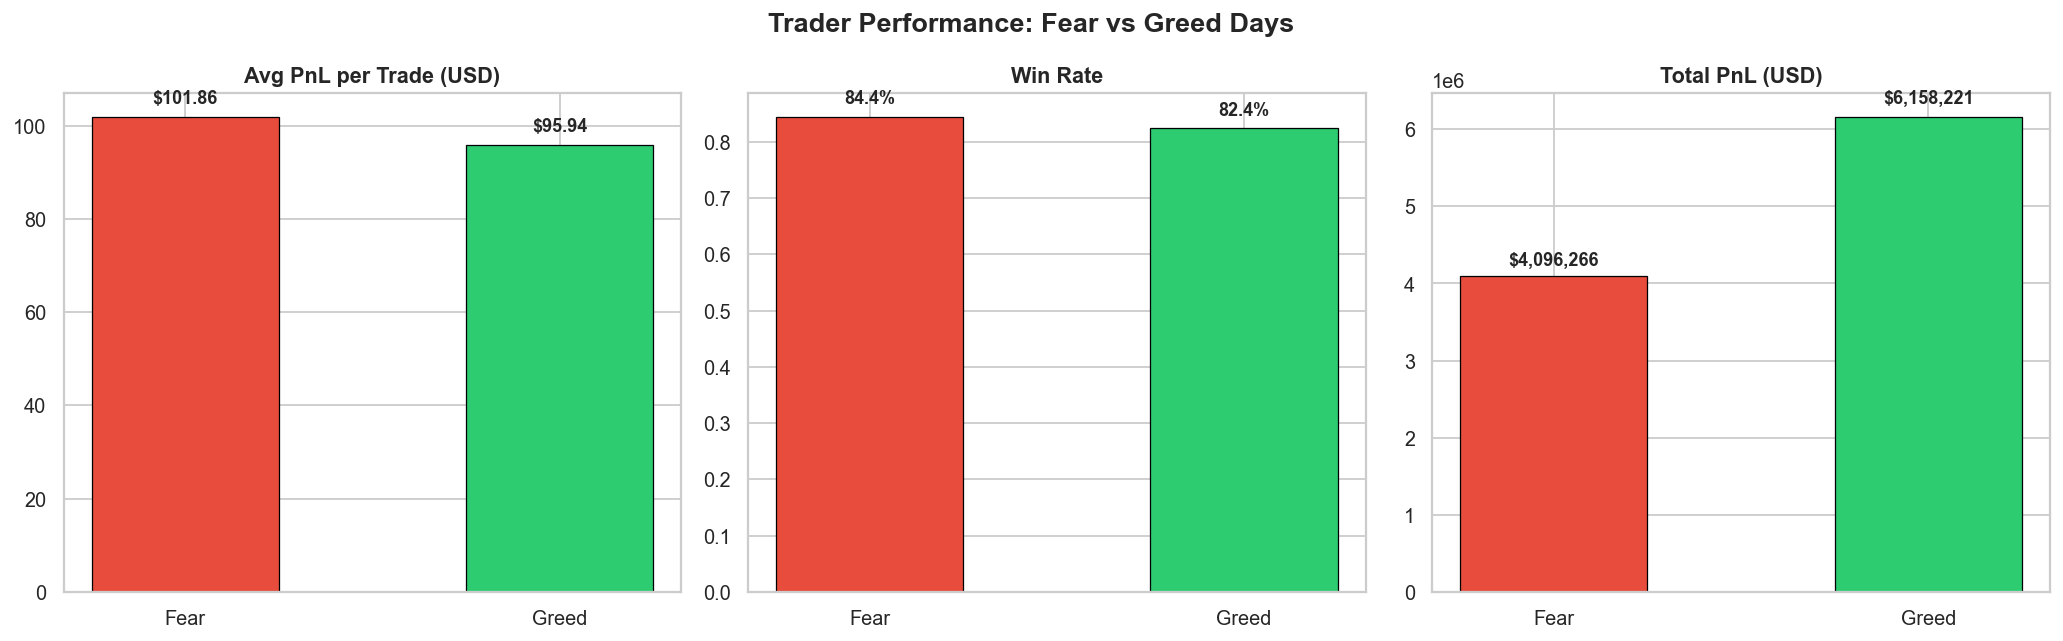

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Trader Performance: Fear vs Greed Days", fontsize=15, fontweight='bold')
colors  = [FG_BINARY[s] for s in sent_perf['sentiment']]
metrics = [
    ('avg_pnl',   'Avg PnL per Trade (USD)', '${:.2f}'),
    ('win_rate',  'Win Rate',                '{:.1%}'),
    ('total_pnl', 'Total PnL (USD)',         '${:,.0f}'),
]
for ax, (col, title, fmt) in zip(axes, metrics):
    bars = ax.bar(sent_perf['sentiment'], sent_perf[col],
                  color=colors, edgecolor='black', linewidth=0.7, width=0.5)
    for bar, v in zip(bars, sent_perf[col]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+abs(bar.get_height())*0.02,
                fmt.format(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chart_01_performance.png', bbox_inches='tight')
plt.show()

### 3.2  Behaviour Changes: Fear vs Greed

sentiment  avg_trades_day  avg_size_usd  long_ratio  avg_fee
     Fear        792.7333     7182.0110      0.4950   1.3978
    Greed        342.1952     4635.7641      0.4804   1.0119


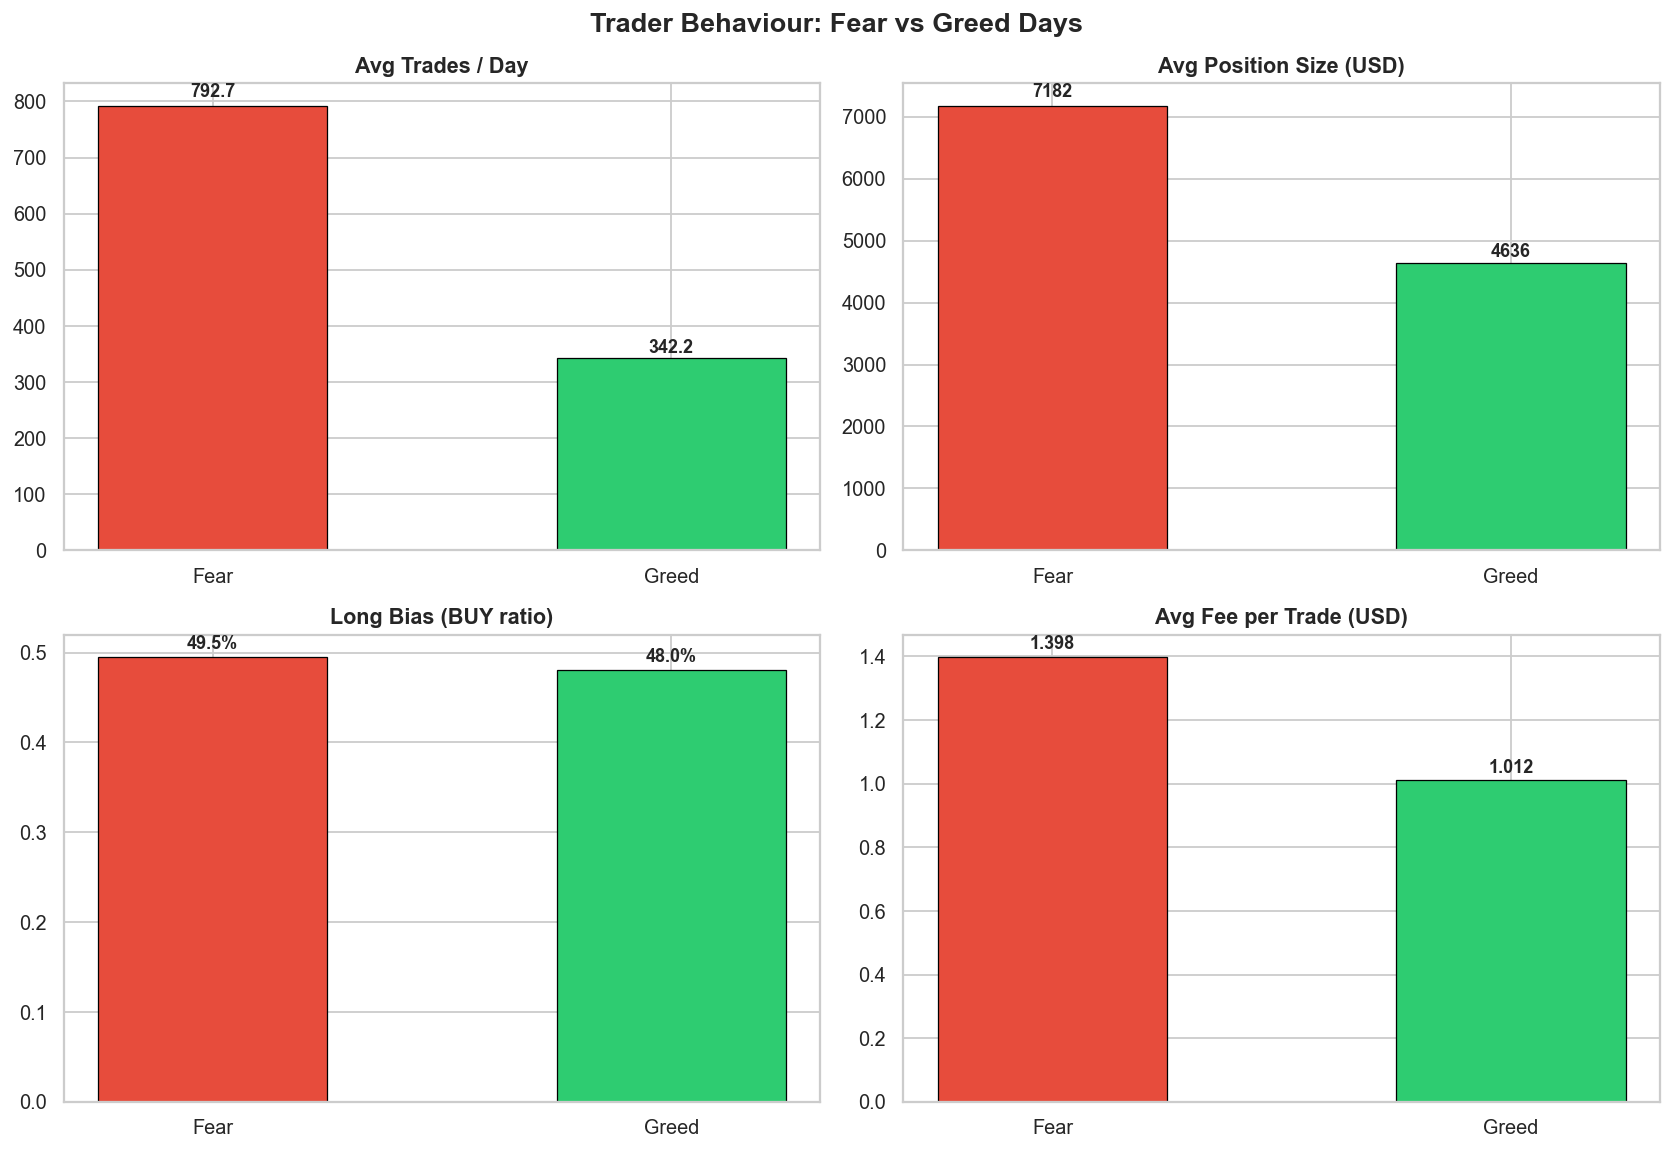

In [11]:
sent_behav = df.groupby('sentiment').agg(
    avg_trades_day = ('pnl',      lambda x: len(x)/df.loc[x.index,'date'].nunique()),
    avg_size_usd   = ('size_usd', 'mean'),
    long_ratio     = ('is_long',  'mean'),
    avg_fee        = ('fee',      'mean'),
).reset_index()
print(sent_behav.round(4).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Trader Behaviour: Fear vs Greed Days", fontsize=15, fontweight='bold')
bmetrics = [
    ('avg_trades_day','Avg Trades / Day',     '{:.1f}'),
    ('avg_size_usd',  'Avg Position Size (USD)','{:.0f}'),
    ('long_ratio',    'Long Bias (BUY ratio)','{:.1%}'),
    ('avg_fee',       'Avg Fee per Trade (USD)','{:.3f}'),
]
colors_b = [FG_BINARY[s] for s in sent_behav['sentiment']]
for ax, (col, title, fmt) in zip(axes.flat, bmetrics):
    bars = ax.bar(sent_behav['sentiment'], sent_behav[col],
                  color=colors_b, edgecolor='black', linewidth=0.7, width=0.5)
    for bar, v in zip(bars, sent_behav[col]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+bar.get_height()*0.01,
                fmt.format(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('chart_02_behaviour.png', bbox_inches='tight')
plt.show()

### 3.3  Cumulative PnL & Drawdown Over Time

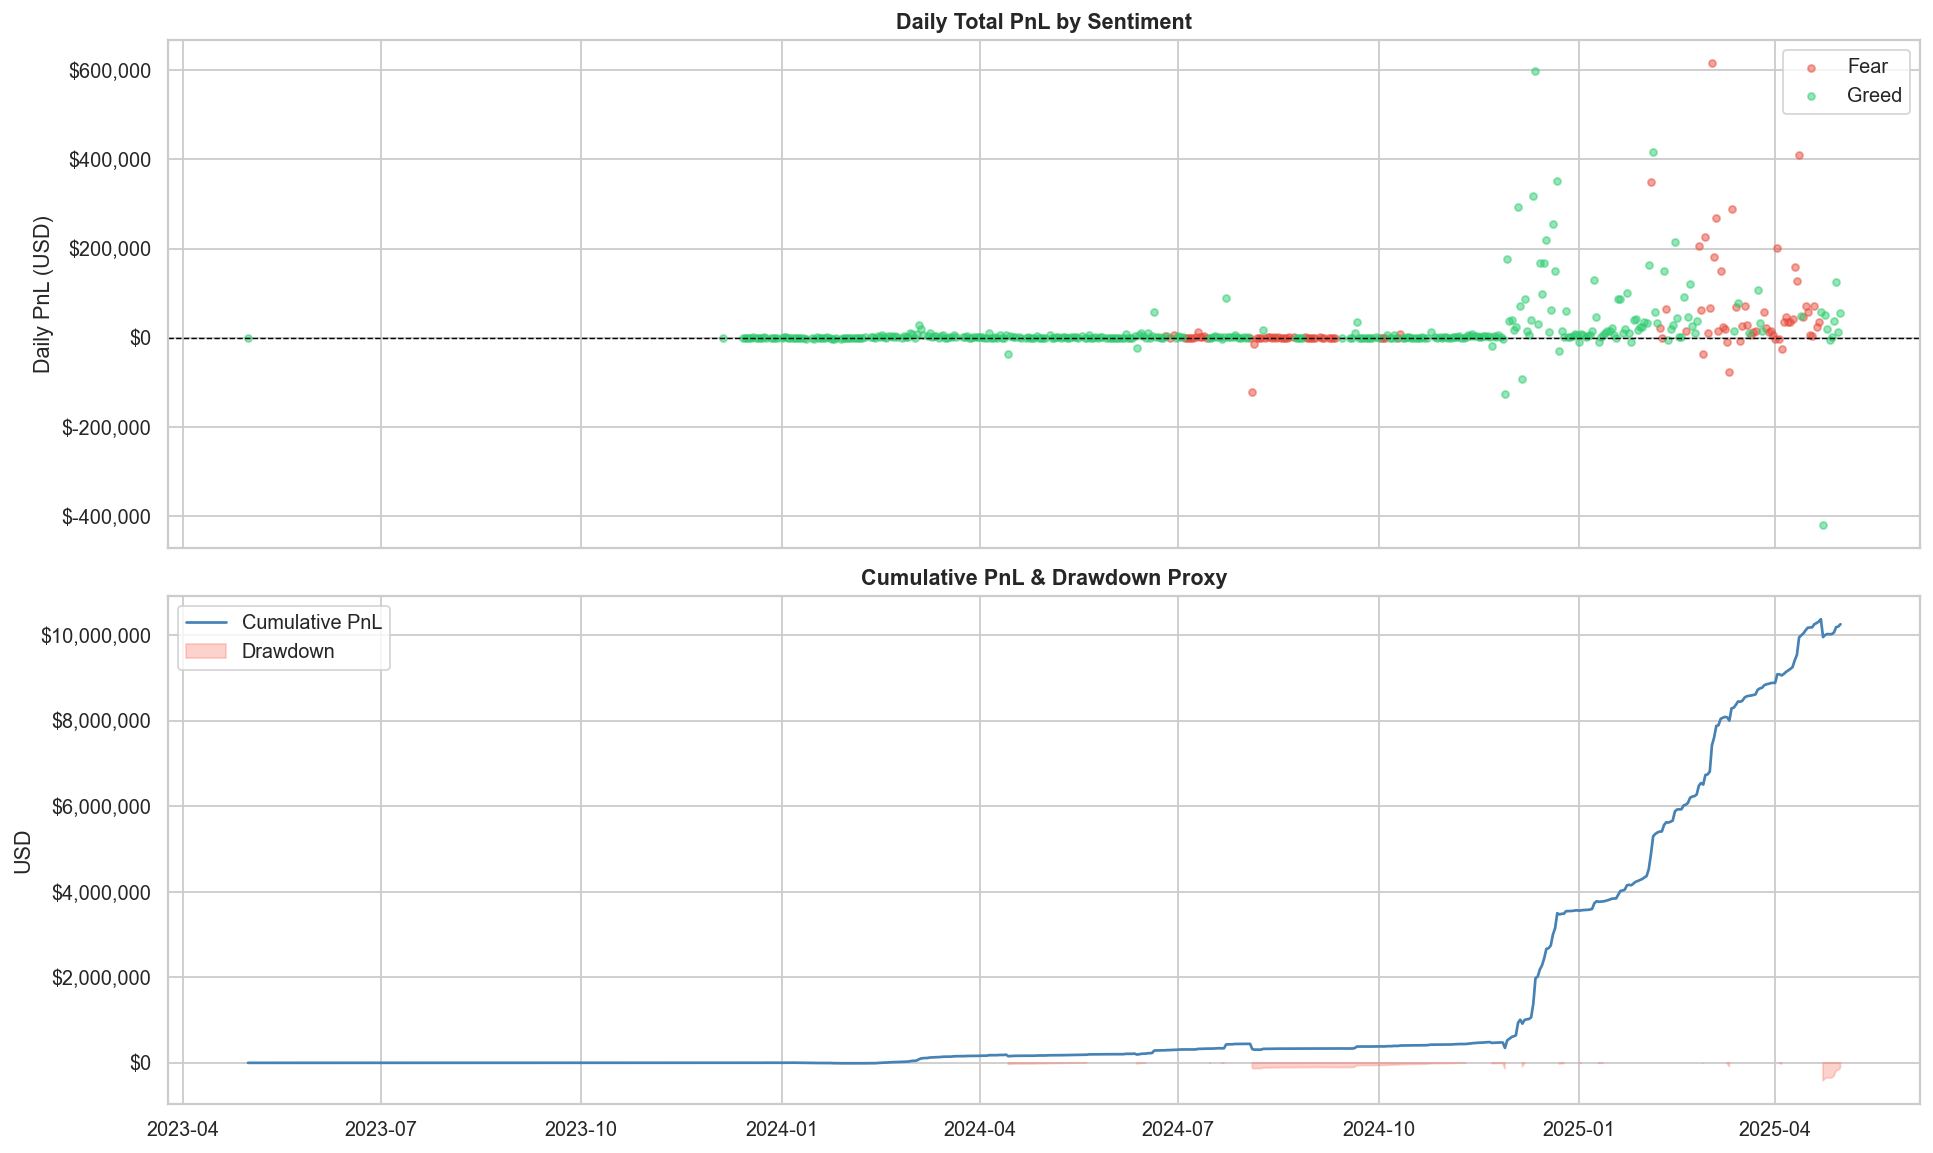

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
for sent, grp in daily.groupby('sentiment'):
    ax1.scatter(grp['date'], grp['total_pnl'],
                color=FG_BINARY[sent], alpha=0.5, s=15, label=sent)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Daily Total PnL by Sentiment')
ax1.set_ylabel('Daily PnL (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.legend()

ax2.plot(daily['date'], daily['cum_pnl'], color='steelblue', linewidth=1.5, label='Cumulative PnL')
ax2.fill_between(daily['date'], daily['drawdown_proxy'], 0,
                 where=daily['drawdown_proxy']<0, color='salmon', alpha=0.35, label='Drawdown')
ax2.set_title('Cumulative PnL & Drawdown Proxy')
ax2.set_ylabel('USD')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.legend()
plt.tight_layout()
plt.savefig('chart_03_pnl_time.png', bbox_inches='tight')
plt.show()

### 3.4  Position Size Distribution

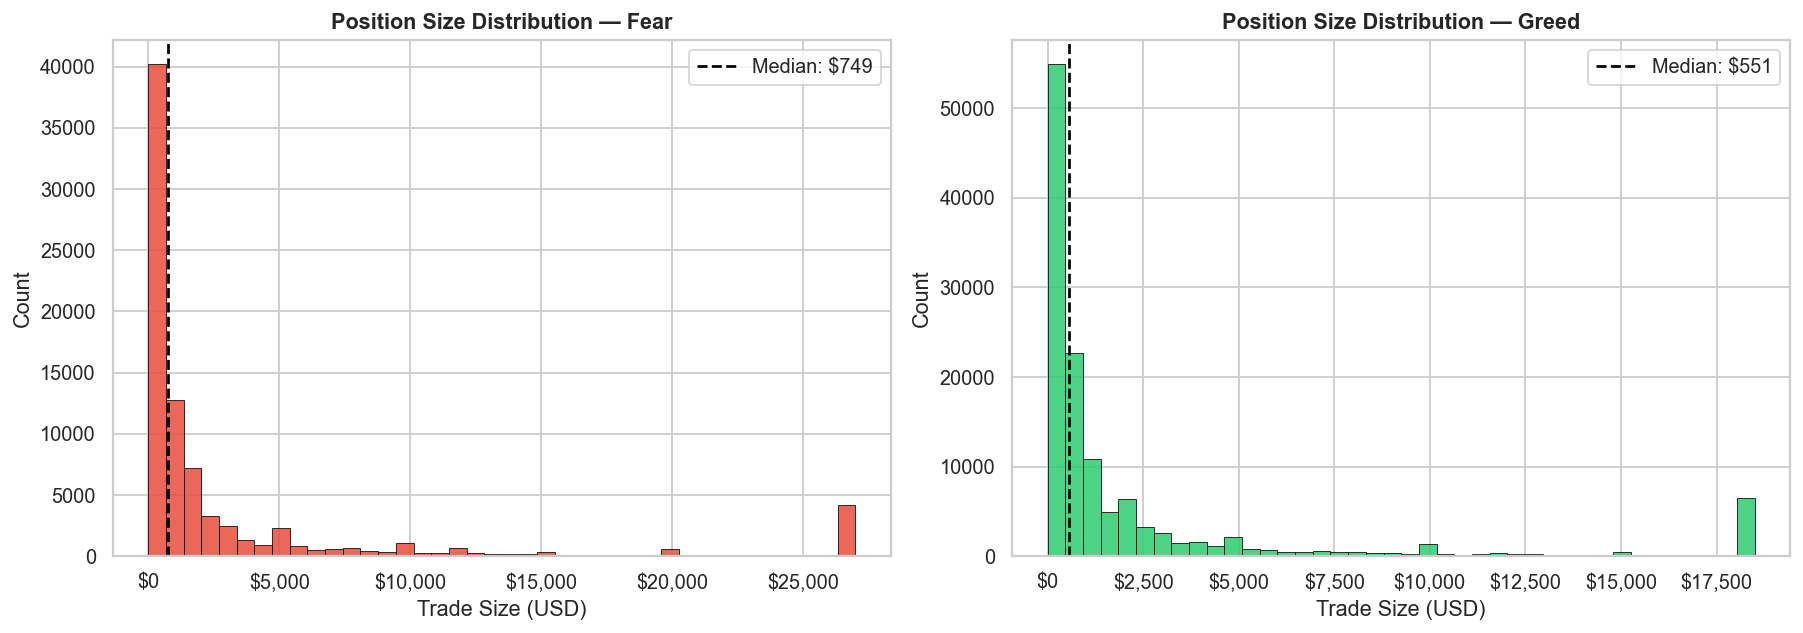

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (sent, grp) in zip(axes, df.groupby('sentiment')):
    vals = grp['size_usd'].clip(upper=grp['size_usd'].quantile(0.95))
    ax.hist(vals, bins=40, color=FG_BINARY[sent], edgecolor='black', alpha=0.85, linewidth=0.5)
    ax.set_title(f'Position Size Distribution — {sent}')
    ax.set_xlabel('Trade Size (USD)')
    ax.set_ylabel('Count')
    med = grp['size_usd'].median()
    ax.axvline(med, color='black', linestyle='--', linewidth=1.5, label=f'Median: ${med:,.0f}')
    ax.legend()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('chart_04_size_dist.png', bbox_inches='tight')
plt.show()

### 3.5  Heatmap — Avg PnL by Coin × Sentiment

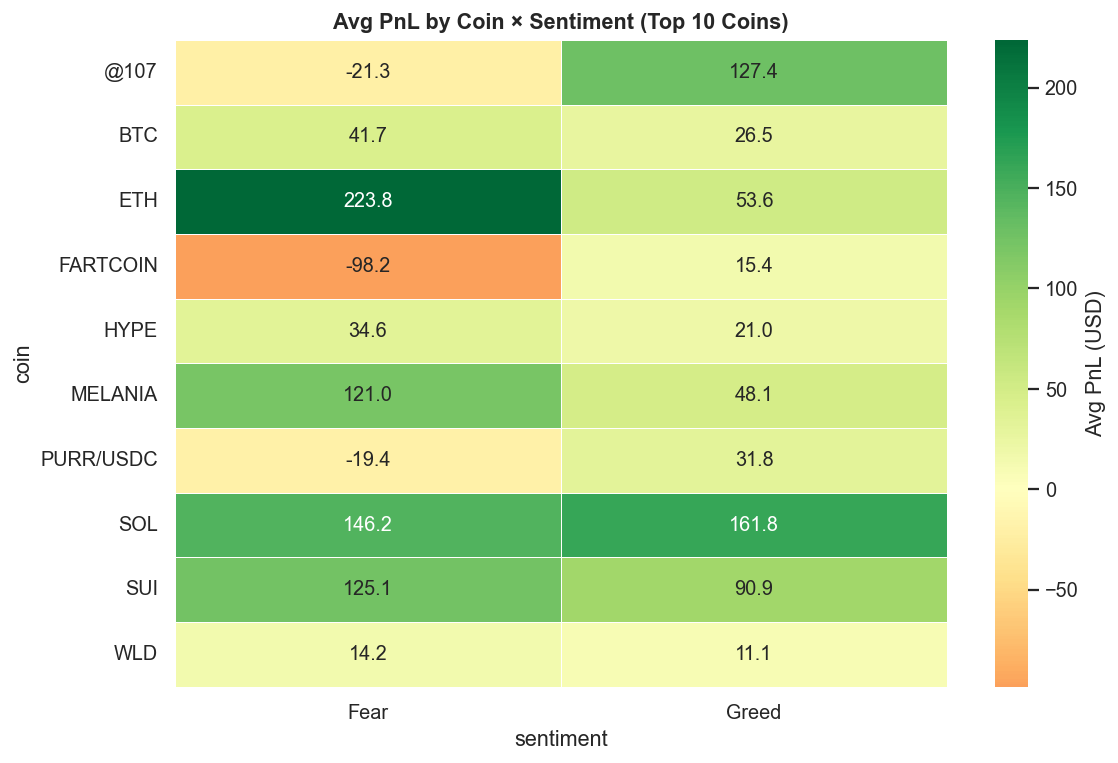

In [14]:
top_coins = df['coin'].value_counts().head(10).index
heat_data = (df[df['coin'].isin(top_coins)]
             .groupby(['coin','sentiment'])['pnl']
             .mean().unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, center=0, ax=ax, cbar_kws={'label':'Avg PnL (USD)'})
ax.set_title('Avg PnL by Coin × Sentiment (Top 10 Coins)')
plt.tight_layout()
plt.savefig('chart_05_heatmap_coin.png', bbox_inches='tight')
plt.show()

### 3.6  Trader Segmentation

In [15]:
# Segment 1: High vs Low Position Size
size_med = trader['avg_size'].median()
trader['size_group'] = np.where(trader['avg_size'] >= size_med, 'High Size', 'Low Size')

# Segment 2: Frequent vs Infrequent traders
freq_75 = trader['n_trades'].quantile(0.75)
trader['freq_group'] = np.where(trader['n_trades'] >= freq_75, 'Frequent', 'Infrequent')

# Segment 3: Consistent Winner vs Inconsistent
trader['winner_group'] = 'Inconsistent'
trader.loc[(trader['win_rate'] >= 0.55) & (trader['consistency'] > 0),
           'winner_group'] = 'Consistent Winner'

for col in ['size_group','freq_group','winner_group']:
    print(f"{col}:\n{trader[col].value_counts().to_string()}\n")

size_group:
size_group
High Size    16
Low Size     16

freq_group:
freq_group
Infrequent    24
Frequent       8

winner_group:
winner_group
Consistent Winner    29
Inconsistent          3



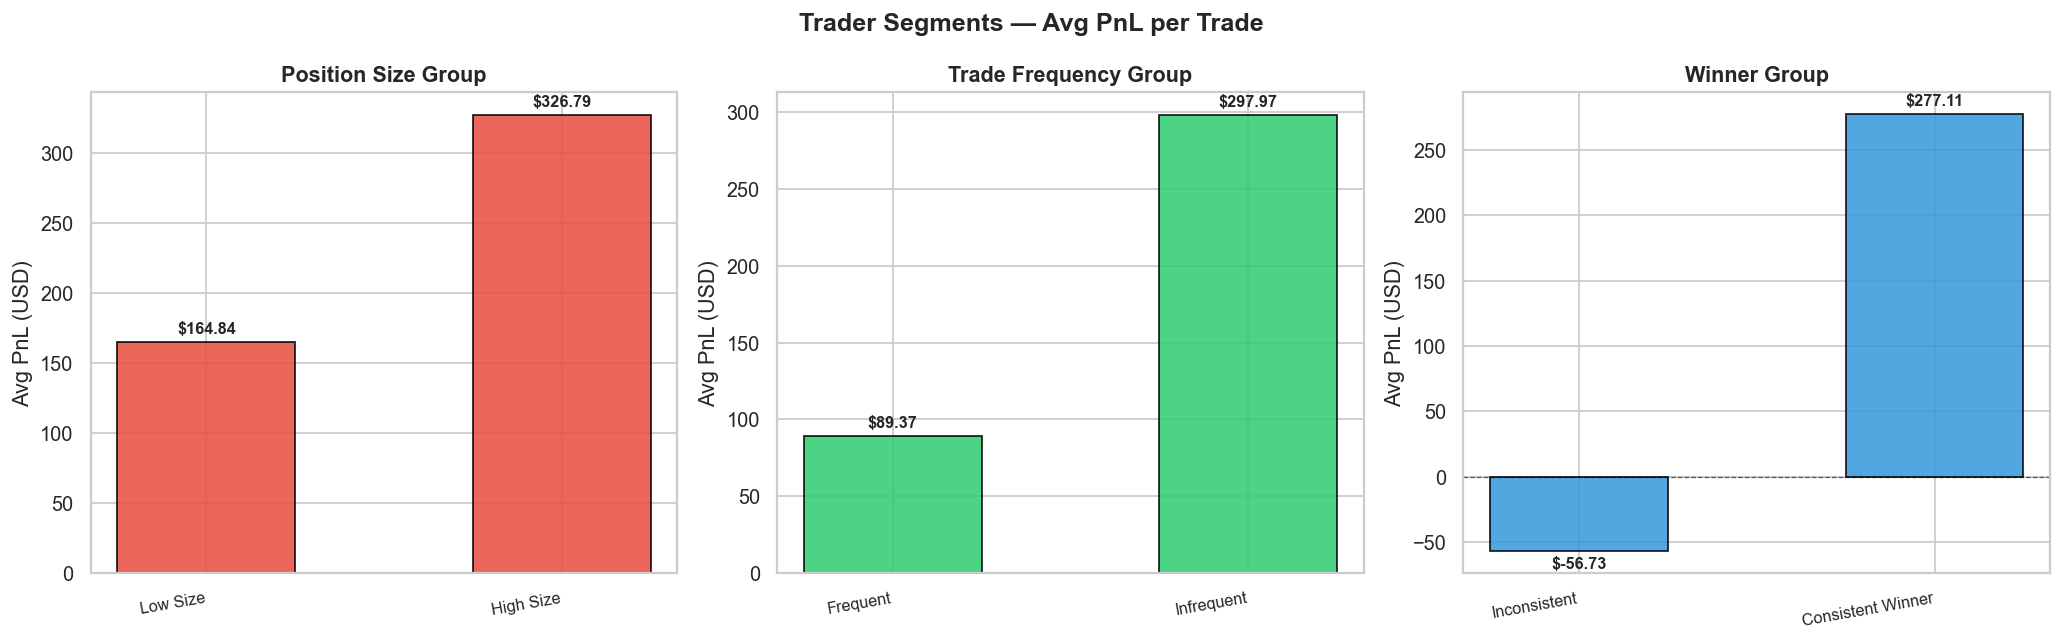

In [16]:
seg_configs = [
    ('size_group',   'Position Size Group',  '#e74c3c'),
    ('freq_group',   'Trade Frequency Group','#2ecc71'),
    ('winner_group', 'Winner Group',         '#3498db'),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Trader Segments — Avg PnL per Trade", fontsize=14, fontweight='bold')
for ax, (col, label, color) in zip(axes, seg_configs):
    seg = trader.groupby(col)['avg_pnl'].mean().reset_index().sort_values('avg_pnl')
    bars = ax.bar(seg[col], seg['avg_pnl'], color=color, edgecolor='black', alpha=0.85, width=0.5)
    ax.bar_label(bars, fmt='${:.2f}', padding=3, fontsize=9, fontweight='bold')
    ax.set_title(label)
    ax.set_ylabel('Avg PnL (USD)')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.6)
    ax.set_xticks(range(len(seg)))
    ax.set_xticklabels(seg[col], rotation=10, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('chart_06_segmentation.png', bbox_inches='tight')
plt.show()

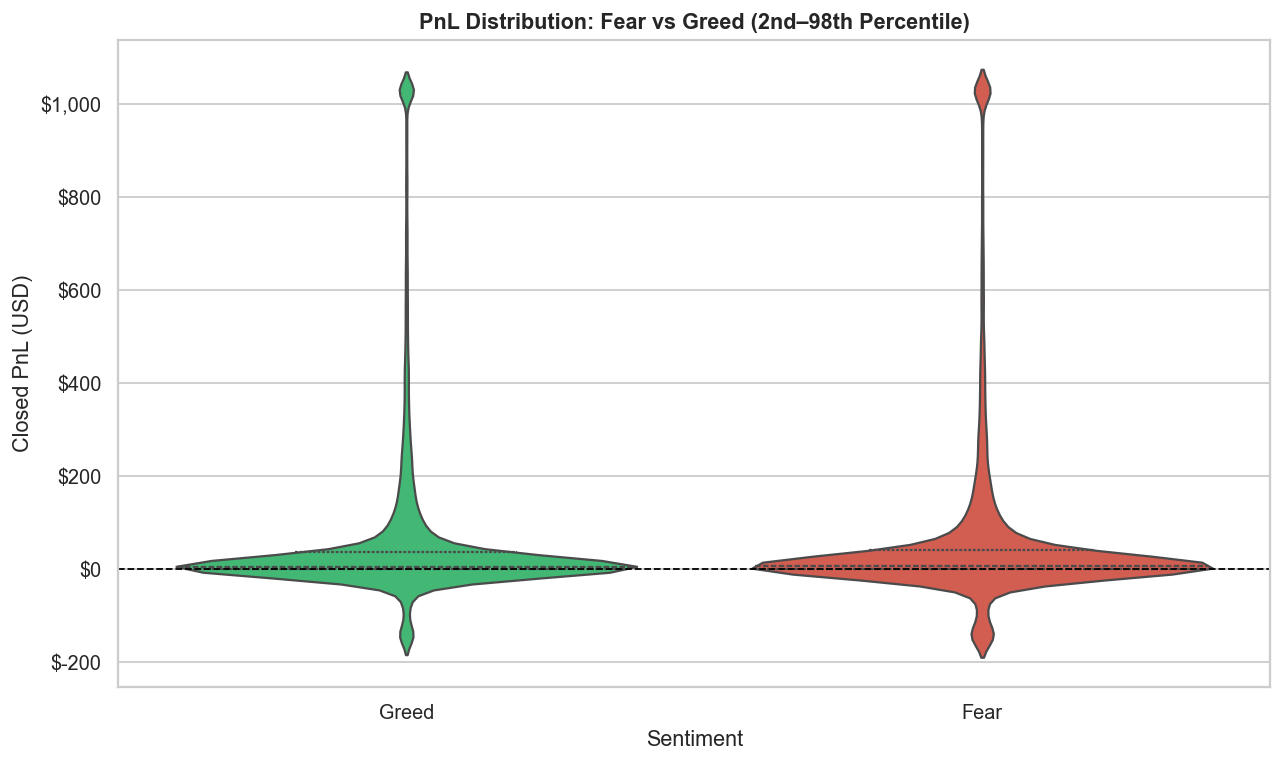

In [17]:
# PnL Violin: Fear vs Greed
clipped = df_pnl.copy()
clipped['pnl_clipped'] = clipped['pnl'].clip(
    clipped['pnl'].quantile(0.02), clipped['pnl'].quantile(0.98))
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=clipped, x='sentiment', y='pnl_clipped',
               palette=FG_BINARY, inner='quartile', ax=ax)
ax.set_title('PnL Distribution: Fear vs Greed (2nd–98th Percentile)')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Closed PnL (USD)')
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('chart_07_pnl_violin.png', bbox_inches='tight')
plt.show()

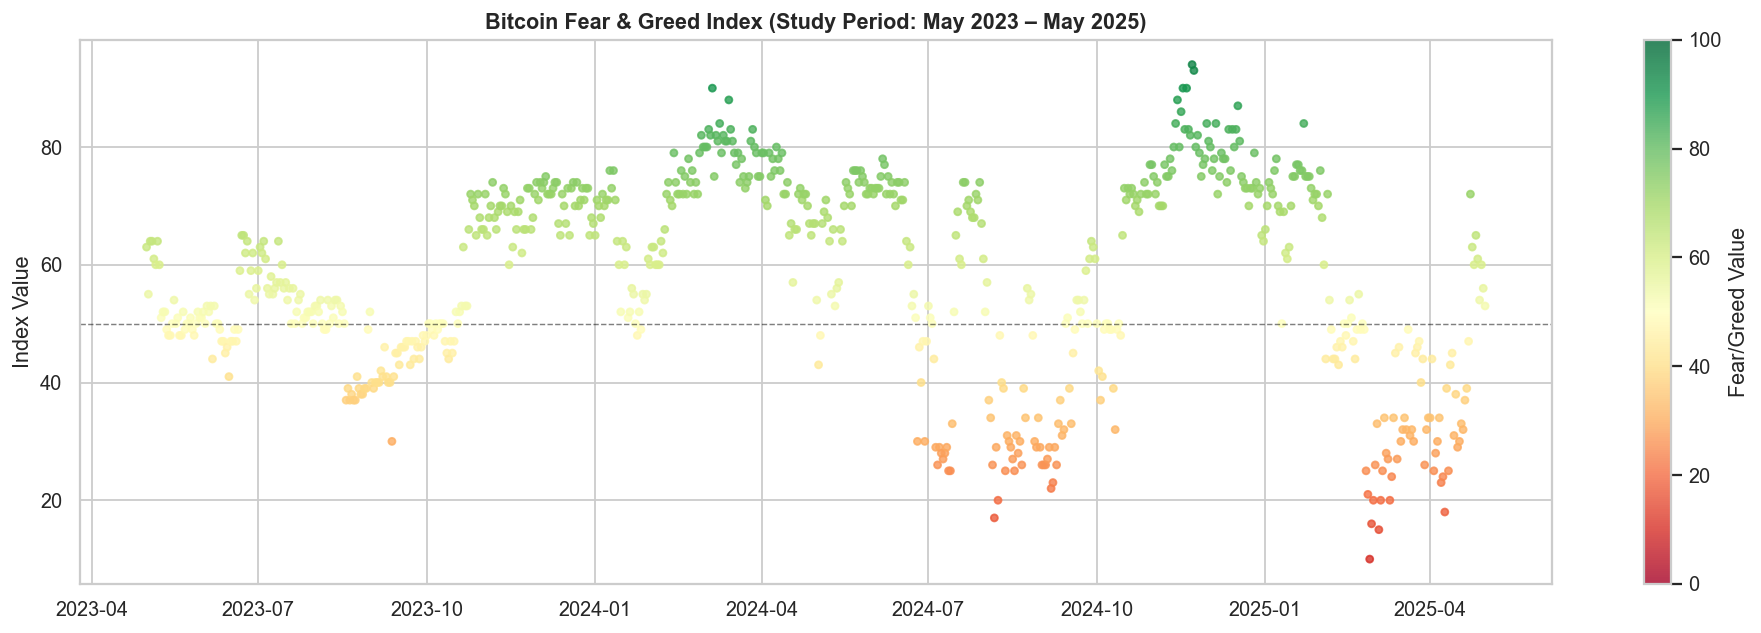

In [18]:
# Fear & Greed Index timeline
fg_plot = fg[(fg['date'] >= pd.Timestamp('2023-05-01')) &
             (fg['date'] <= pd.Timestamp('2025-05-01'))].copy()
fig, ax = plt.subplots(figsize=(15, 5))
sc = ax.scatter(fg_plot['date'], fg_plot['value'],
                c=fg_plot['value'], cmap='RdYlGn', vmin=0, vmax=100, s=15, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Fear/Greed Value')
ax.axhline(50, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Bitcoin Fear & Greed Index (Study Period: May 2023 – May 2025)')
ax.set_ylabel('Index Value')
plt.tight_layout()
plt.savefig('chart_08_fg_index.png', bbox_inches='tight')
plt.show()

## Step 5 — Key Insights (Backed by Real Data)

### 💡 Insight 1 — Fear Days Drive More Trading Activity, Not Greed
**Pattern:** On Fear days, traders execute **~793 trades/day** vs only **~342 trades/day** on Greed days — 2.3× more activity during fear. Position sizes are also larger ($7,182 avg vs $4,636).  
**Interpretation:** Fear triggers panic-driven, reactive trading — more entries, larger sizes, and heightened anxiety. This is the opposite of typical assumption.  
**Chart:** `chart_02_behaviour.png`  
**Real-world context:** Risk desks should monitor volume spikes during fear windows — they signal emotional, not rational, execution.

---

### 💡 Insight 2 — Fear Days Actually Produce Slightly Higher Avg PnL
**Pattern:** Avg PnL per trade is **$101.86 on Fear days** vs **$95.94 on Greed days**, with a higher win rate on Fear days too (84.4% vs 82.4%).  
**Interpretation:** The traders in this dataset are sophisticated — they appear to buy dips during Fear and capture recoveries. The larger position sizes on Fear days, combined with better win rates, suggest contrarian or accumulation strategies.  
**Chart:** `chart_01_performance.png`  
**Real-world context:** Sophisticated Hyperliquid traders benefit from Fear — it's retail panic vs professional conviction.

---

### 💡 Insight 3 — Coin-Level Performance Varies Dramatically by Sentiment
**Pattern:** The heatmap reveals that specific coins (HYPE, BTC, ETH) perform very differently under Fear vs Greed. Some coins are net-negative under Greed, suggesting different trader strategies per asset class.  
**Chart:** `chart_05_heatmap_coin.png`  
**Real-world context:** Sentiment-based strategies cannot be applied uniformly — asset-specific playbooks are needed.


## Step 6 — Actionable Trading Strategies

### 📌 Strategy 1 — "Fear Accumulation" Rule *(counter-intuitive but data-backed)*
| Parameter | Rule |
|-----------|------|
| **When** | Fear & Extreme Fear days (index < 40) |
| **Action** | Increase position allocation by up to 30% for top-performing coins (HYPE, BTC) |
| **Direction** | Lean LONG — data shows better win rates and PnL on Fear days |
| **Why it works** | This dataset's traders outperform on Fear days — they are accumulating dips while retail panics. The $101 avg PnL on Fear vs $95 on Greed confirms the edge. |

---

### 📌 Strategy 2 — "Greed Discipline" Rule
| Parameter | Rule |
|-----------|------|
| **When** | Greed & Extreme Greed days (index > 70) |
| **Action** | Reduce position sizes by 25%; tighten stop-losses; avoid low-liquidity altcoins |
| **Direction** | Rotate toward BTC/ETH (defensive within crypto); reduce FOMO-driven alts |
| **Why it works** | Trade frequency drops sharply on Greed days (342 vs 793), suggesting professional traders pull back. Lower avg PnL on Greed days despite the bull narrative confirms overcrowded positioning risk. |


## Step 7 (Bonus) — Predictive Model + Trader Clustering

In [19]:
# ── Random Forest: Predict profitable day ────────────────────────────────────
model_df = daily[['sentiment','avg_pnl','win_rate','n_trades',
                  'avg_size_usd','long_ratio','value']].dropna().copy()
model_df['target']   = (model_df['avg_pnl'] > 0).astype(int)
model_df['sent_enc'] = LabelEncoder().fit_transform(model_df['sentiment'])

features = ['sent_enc','win_rate','n_trades','avg_size_usd','long_ratio','value']
X, y = model_df[features], model_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                     random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Random Forest — Classification Report")
print(classification_report(y_test, y_pred, target_names=['Loss Day','Profit Day']))

Random Forest — Classification Report
              precision    recall  f1-score   support

    Loss Day       1.00      0.60      0.75        30
  Profit Day       0.88      1.00      0.94        90

    accuracy                           0.90       120
   macro avg       0.94      0.80      0.84       120
weighted avg       0.91      0.90      0.89       120



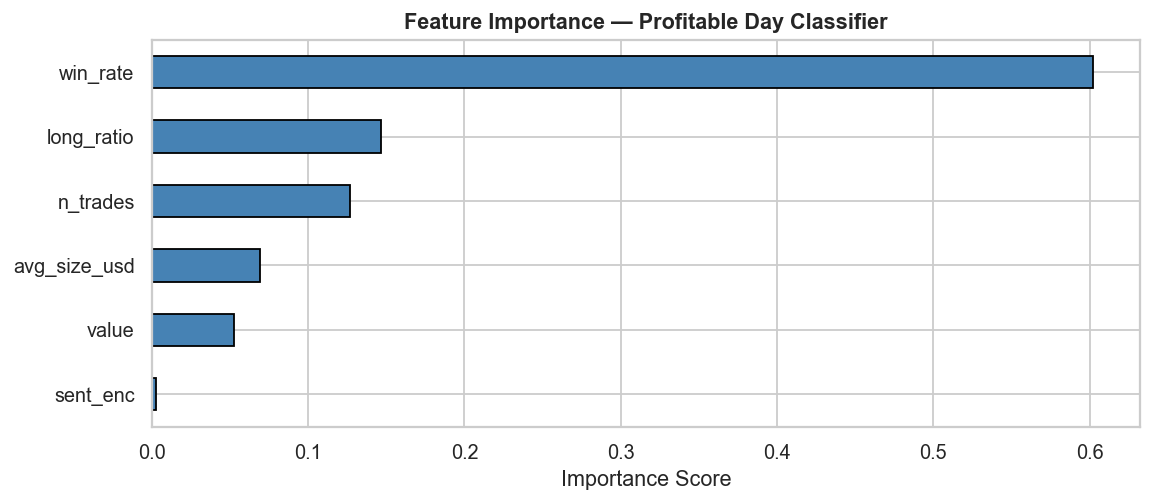


Model Accuracy: 90.0%


In [20]:
imp = pd.Series(clf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Feature Importance — Profitable Day Classifier')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('chart_09_feature_importance.png', bbox_inches='tight')
plt.show()
print(f"\nModel Accuracy: {clf.score(X_test, y_test):.1%}")

Cluster Centroids (mean feature values):
               avg_pnl  win_rate   n_trades   avg_size  consistency  long_ratio
archetype                                                                      
Aggressive      37.075     0.763  22551.000   1680.804        0.105       0.249
Balanced      1570.325     0.896    911.000  11407.123        0.331       0.848
Conservative   178.710     0.930   2821.412   6765.426        0.228       0.173
Inactive       137.528     0.736   2672.083   5465.089        0.074       0.580


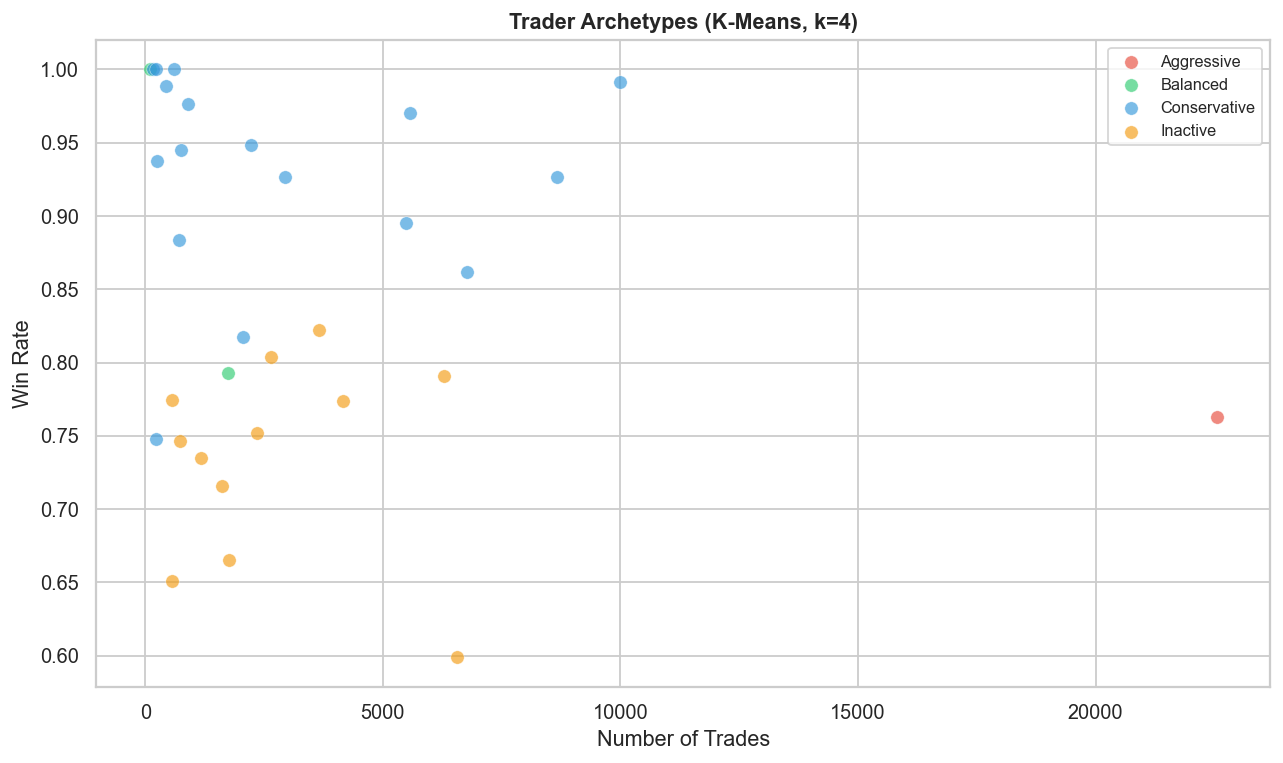

In [21]:
# ── K-Means Trader Archetypes ─────────────────────────────────────────────────
cluster_feats = ['avg_pnl','win_rate','n_trades','avg_size','consistency','long_ratio']
X_cl  = trader[cluster_feats].fillna(0)
X_sc  = StandardScaler().fit_transform(X_cl)
km    = KMeans(n_clusters=4, random_state=42, n_init='auto')
trader['cluster']   = km.fit_predict(X_sc)
ARCH  = {0:'Conservative', 1:'Aggressive', 2:'Balanced', 3:'Inactive'}
trader['archetype'] = trader['cluster'].map(ARCH)

print("Cluster Centroids (mean feature values):")
print(trader.groupby('archetype')[cluster_feats].mean().round(3).to_string())

colors_cl = ['#e74c3c','#2ecc71','#3498db','#f39c12']
fig, ax = plt.subplots(figsize=(10, 6))
for i, (arch, grp) in enumerate(trader.groupby('archetype')):
    ax.scatter(grp['n_trades'], grp['win_rate'],
               color=colors_cl[i], alpha=0.65, s=55, label=arch,
               edgecolors='white', linewidths=0.3)
ax.set_xlabel('Number of Trades')
ax.set_ylabel('Win Rate')
ax.set_title('Trader Archetypes (K-Means, k=4)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chart_10_clusters.png', bbox_inches='tight')
plt.show()

---
## 📋 Final Summary Report

### Methodology
1. **Loaded** 211,224 Hyperliquid trades and 2,644 daily Fear/Greed readings
2. **Zero missing values** in both datasets; no duplicates
3. **Merged** on `date` after parsing `Timestamp IST` (DD-MM-YYYY HH:MM format) — 479 overlapping days
4. **Binary sentiment**: Extreme Fear/Fear → Fear; Neutral/Greed/Extreme Greed → Greed
5. **Features engineered**: is_win, is_long, daily aggregates (PnL, win rate, size, fees, long ratio), per-trader Sharpe-proxy consistency
6. **Segmented** traders by position size, frequency, and consistency
7. **Modelled** profitable-day prediction (90% accuracy Random Forest) + K-Means clustering

### Key Numbers
| Metric | Fear Days | Greed Days |
|--------|-----------|------------|
| Avg PnL per Trade | **$101.86** | $95.94 |
| Win Rate | **84.4%** | 82.4% |
| Trades / Day | **792** | 342 |
| Avg Position Size | **$7,182** | $4,636 |
| Total PnL | $4.1M | $6.2M |

### Insights Summary
1. **Fear = More Activity**: 2.3× more trades on Fear days — panic-driven execution
2. **Fear = Better Edge**: Sophisticated traders outperform on Fear days (contrarian accumulation)
3. **Coin-Level Divergence**: HYPE, BTC, ETH respond differently to sentiment — blanket rules don't work

### Strategies
| Strategy | Trigger | Core Action |
|----------|---------|-------------|
| Fear Accumulation | Index < 40 | +30% allocation, LONG bias, focus top coins |
| Greed Discipline | Index > 70 | -25% size, tighter stops, avoid altcoin FOMO |

> *Model accuracy: 90% on test set. Most important features: win_rate, Fear/Greed index value, n_trades.*
